<a href="https://colab.research.google.com/github/veapasichnyk/HomeWorksDataLovesAcademy/blob/main/HW_2_2_%D0%9B%D0%BE%D0%B3%D1%96%D1%81%D1%82%D0%B8%D1%87%D0%BD%D0%B0_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%8F_%D0%B7_scikit_learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import opendatasets as od
import os
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, f1_score, accuracy_score


В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [2]:
!pip install opendatasets --upgrade --quiet

In [3]:
od.version()

'0.1.22'

In [4]:
dataset_url = 'https://www.kaggle.com/competitions/bank-customer-churn-prediction-dlu-course-c-3/data?select=train.csv'

In [5]:
od.download(dataset_url)

Skipping, found downloaded files in "./bank-customer-churn-prediction-dlu-course-c-3" (use force=True to force download)


In [6]:
data_dir = './bank-customer-churn-prediction-dlu-course-c-3'

In [7]:
os.listdir(data_dir)

['train.csv', 'sample_submission.csv', 'test.csv']

In [8]:
train_csv = data_dir + '/train.csv'

In [9]:
train_df = pd.read_csv(train_csv)

In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


In [11]:
X = train_df.drop('Exited', axis=1)
y = train_df['Exited']

In [12]:
# Розбиття з урахуванням стратифікації
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [13]:
print("Форма X_train:", X_train.shape)
print("Форма X_val:", X_val.shape)
print("Розподіл класів у train:\n", y_train.value_counts(normalize=True))
print("Розподіл класів у validation:\n", y_val.value_counts(normalize=True))

Форма X_train: (12000, 13)
Форма X_val: (3000, 13)
Розподіл класів у train:
 Exited
0.0    0.7965
1.0    0.2035
Name: proportion, dtype: float64
Розподіл класів у validation:
 Exited
0.0    0.796667
1.0    0.203333
Name: proportion, dtype: float64


2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [14]:
# Вхідні колонки — всі, крім цільової
input_cols = [col for col in train_df.columns if col != 'Exited']

# Формування піднаборів
train_inputs = X_train[input_cols]
train_targets = y_train

val_inputs = X_val[input_cols]
val_targets = y_val

# Перевірка форм
print("train_inputs shape:", train_inputs.shape)
print("train_targets shape:", train_targets.shape)
print("val_inputs shape:", val_inputs.shape)
print("val_targets shape:", val_targets.shape)

train_inputs shape: (12000, 13)
train_targets shape: (12000,)
val_inputs shape: (3000, 13)
val_targets shape: (3000,)


3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [15]:
# Визначення числових колонок
numeric_cols = train_inputs.select_dtypes(include=['number']).columns.tolist()

# Визначення категоріальних колонок
categorical_cols = train_inputs.select_dtypes(include=['object', 'category']).columns.tolist()

print("Числові колонки:", numeric_cols)
print("Категоріальні колонки:", categorical_cols)

Числові колонки: ['id', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Категоріальні колонки: ['Surname', 'Geography', 'Gender']


**Спостереження**

Отже, ми отримали список числових та категоріальних колонок, але не всі ці колонки варто залишати як вхідні ознаки в моделі:

- `id` та `CustomerId` — ідентифікатори, які не несуть інформації для прогнозу → потрібно виключити.

- `Surname` — скоріше за все неінформативна для моделі → її також доцільно виключити.


In [16]:
# Оновлення списків, виключаючи зайві колонки
numeric_cols = [col for col in numeric_cols if col not in ['id', 'CustomerId']]
categorical_cols = [col for col in categorical_cols if col not in ['Surname']]

# Формуємо фінальний список колонок для моделі
input_cols = numeric_cols + categorical_cols

print("Вхідні колонки:", input_cols)

Вхідні колонки: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography', 'Gender']


In [17]:
#Оновлюємо input-дані
train_inputs = X_train[input_cols]
val_inputs = X_val[input_cols]

In [18]:
train_inputs[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00
mean,658.84,37.69,5.03,43008.17,1.59,0.79,0.49,117992.40
std,72.33,8.14,2.78,59906.63,0.53,0.41,0.50,45589.48
min,431.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58
25%,603.00,32.00,3.00,0.00,1.00,1.00,0.00,83343.73
50%,661.00,37.00,5.00,0.00,2.00,1.00,0.00,123613.91
75%,708.00,42.00,7.00,109949.05,2.00,1.00,1.00,156912.81
max,850.00,74.00,10.00,209767.31,4.00,1.00,1.00,199992.48


**Спостереження**

`CreditScore` (Кредитний рейтинг):

Середнє значення кредитного рейтингу складає 658.84, стандартне відхилення - 72.33. Рейтинги варіюються від 431 до 850, що свідчить про те, що більшість клієнтів мають середній рейтинг, а кілька знаходяться на екстремальних значеннях.

`Age` (Вік): Середній вік - 37 років, мінімум - 18, максимум - 74. Стандартне відхилення (8.14) показує, що в даних є чимала варіативність за віком.

`Tenure` (Тривалість обслуговування):  

Середній показник - 5.03 роки, діапазон від 0 до 10 років.

`Balance` (Баланс):  

Середній баланс - 43,008.17, але діапазон варіюється від 0 до 209,767.31, що вказує на те, що деякі клієнти мають значно більші баланси, ніж більшість.

`NumOfProducts` (Кількість продуктів):  

Середня кількість продуктів на клієнта - 1.59, максимум - 4. Більшість клієнтів використовують 1 або 2 продукти, хоча є й кілька з більшою кількістю.

`HasCrCard` (Має кредитну картку):

Цей бінарний стовпець вказує, чи є у клієнта кредитна картка (1 - так, 0 - ні). Приблизно 79% клієнтів мають кредитну картку.

`IsActiveMember` (Активний клієнт):

Цей стовпець показує, чи є клієнт активним (1 - так, 0 - ні). Половина клієнтів є активними учасниками, що вказує на збалансовану пропорцію активних і неактивних клієнтів.

`EstimatedSalary` (Оцінена зарплата):

Середня оцінена зарплата - 117,992.40, при цьому діапазон варіюється від 11.58 до 199,992.48, що свідчить про значні відмінності в заробітках клієнтів.

In [19]:
train_inputs[categorical_cols].nunique()

,0
Geography,3
Gender,2


**Спостереження**

`Geography` (Географія):

Є 3 категорії, що означає, що в даному стовпці є три можливі значення регіонів.

`Gender` (Стать):

Є 2 категорії - "чоловік" та "жінка"

4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

In [20]:
# Копії даних (щоб зберегти оригінали)
train_df = train_inputs.copy()
val_df = val_inputs.copy()

**Заповнення пропусків**
- Числові ознаки:

Заповнюємо медіаною (робить модель менш чутливою до викидів).

- Категоріальні ознаки:

Заповнюємо значенням 'missing' — логічний підхід, який дозволяє моделі врахувати сам факт відсутності

In [21]:
# Числові колонки: медіаною
num_imputer = SimpleImputer(strategy='median')
train_df[numeric_cols] = num_imputer.fit_transform(train_df[numeric_cols])
val_df[numeric_cols] = num_imputer.transform(val_df[numeric_cols])

In [22]:
# Категоріальні — "missing"
cat_imputer = SimpleImputer(strategy='constant', fill_value='missing')
train_cat_imputed = pd.DataFrame(
    cat_imputer.fit_transform(train_df[categorical_cols]),
    columns=categorical_cols,
    index=train_df.index
)
val_cat_imputed = pd.DataFrame(
    cat_imputer.transform(val_df[categorical_cols]),
    columns=categorical_cols,
    index=val_df.index
)

# Повертаємо назад у датафрейм
train_df[categorical_cols] = train_cat_imputed
val_df[categorical_cols] = val_cat_imputed

**Масштабування числових ознак**

Застосовуємо StandardScaler (зменшує вплив ознак з великим діапазоном, як-от EstimatedSalary, Balance).

In [23]:
# Масштабування числових
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[numeric_cols])
val_scaled = scaler.transform(val_df[numeric_cols])

train_num_df = pd.DataFrame(train_scaled, columns=numeric_cols, index=train_df.index)
val_num_df = pd.DataFrame(val_scaled, columns=numeric_cols, index=val_df.index)

**Кодування категоріальних ознак**

OneHotEncoder(drop='first') - уникаємо multicollinearity і перетворюємо Geography та Gender на числові.

In [24]:
# Перевіримо categorical_cols
print("Категоріальні колонки:", categorical_cols)
print("train_df[categorical_cols].shape:", train_df[categorical_cols].shape)

Категоріальні колонки: ['Geography', 'Gender']
train_df[categorical_cols].shape: (12000, 2)


In [25]:
# Кодування обох колонок одночасно
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
train_encoded = encoder.fit_transform(train_df[categorical_cols])
val_encoded = encoder.transform(val_df[categorical_cols])

# Перевіримо форму і назви колонок
print("train_encoded.shape:", train_encoded.shape)
encoded_cat_cols = encoder.get_feature_names_out(categorical_cols)
print("encoded_cat_cols:", encoded_cat_cols)

train_encoded.shape: (12000, 3)
encoded_cat_cols: ['Geography_Germany' 'Geography_Spain' 'Gender_Male']


In [26]:
# Тепер створюємо DataFrame
train_cat_df = pd.DataFrame(train_encoded, columns=encoded_cat_cols, index=train_df.index)
val_cat_df = pd.DataFrame(val_encoded, columns=encoded_cat_cols, index=val_df.index)

In [27]:
#Об’єднуємо числові + закодовані категоріальні
train_inputs_final = pd.concat([train_num_df, train_cat_df], axis=1)
val_inputs_final = pd.concat([val_num_df, val_cat_df], axis=1)

In [28]:
#Виводимо результат

print("Оброблені тренувальні дані:")
display(train_inputs_final.head())

print("Оброблені валідаційні дані:")
display(val_inputs_final.head())

Оброблені тренувальні дані:


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
7180,0.320187,-0.944682,-1.447264,1.475464,-1.108193,0.515062,1.016977,0.569450,0.0,0.0,1.0
10393,0.347838,0.161227,-1.087792,2.254434,-1.108193,0.515062,-0.983306,0.603803,0.0,0.0,0.0
80,0.638166,-0.330288,0.350096,1.223831,0.769304,0.515062,-0.983306,1.238026,1.0,0.0,1.0
3365,0.140460,2.495924,-1.806736,-0.717950,0.769304,-1.941514,1.016977,-1.457116,0.0,1.0,1.0
12236,0.665816,-2.050591,-0.728320,-0.717950,0.769304,0.515062,1.016977,0.670629,0.0,0.0,1.0


Оброблені валідаційні дані:


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
6490,0.762592,1.021379,-1.447264,1.214543,4.524299,0.515062,1.016977,-0.988144,1.0,0.0,1.0
3646,-0.910252,0.406985,-0.009376,-0.717950,0.769304,0.515062,1.016977,-1.750392,0.0,0.0,1.0
5306,0.997620,0.038348,-1.087792,-0.717950,0.769304,-1.941514,1.016977,-0.022404,0.0,0.0,0.0
652,0.195761,0.652742,-0.368848,1.881867,-1.108193,-1.941514,1.016977,-0.139723,0.0,0.0,0.0
2627,0.264887,-0.944682,-0.368848,-0.717950,0.769304,0.515062,-0.983306,0.563519,0.0,1.0,0.0


5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [29]:
#Створимо директорію для збереження
save_dir = "prepared_data"
os.makedirs(save_dir, exist_ok=True)

In [30]:
#Збереження в parquet
train_inputs_final.to_parquet(os.path.join(save_dir, "train_inputs.parquet"))
train_targets.to_frame(name="target").to_parquet(os.path.join(save_dir, "train_targets.parquet"))
val_inputs_final.to_parquet(os.path.join(save_dir, "val_inputs.parquet"))
val_targets.to_frame(name="target").to_parquet(os.path.join(save_dir, "val_targets.parquet"))

In [31]:
# Перевірка: список файлів у директорії
print("Список збережених файлів у папці 'prepared_data':")
print(os.listdir(save_dir))

Список збережених файлів у папці 'prepared_data':
['train_targets.parquet', 'val_targets.parquet', 'train_inputs.parquet', 'val_inputs.parquet']


6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [32]:
#Створимо X та y
X_train = train_inputs_final.copy()
X_val = val_inputs_final.copy()

y_train = train_targets.copy()
y_val = val_targets.copy()

In [33]:
#Створення і навчання моделі
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [34]:
#Перевіримо точність на train і validation
train_score = model.score(X_train, y_train)
val_score = model.score(X_val, y_val)

print(f"Точність на train: {train_score:.4f}")
print(f"Точність на validation: {val_score:.4f}")

Точність на train: 0.8745
Точність на validation: 0.8697


7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

In [35]:
#Ймовірності від моделі
y_train_proba = model.predict_proba(X_train)[:, 1]
y_val_proba = model.predict_proba(X_val)[:, 1]

In [36]:
#Класифікація за порогом 0.5
y_train_pred = (y_train_proba >= 0.5).astype(int)
y_val_pred = (y_val_proba >= 0.5).astype(int)

In [37]:
# Train
train_cm = confusion_matrix(y_train, y_train_pred)
train_auc = roc_auc_score(y_train, y_train_proba)
train_f1 = f1_score(y_train, y_train_pred)

print("TRAIN METRICS")
print("Confusion Matrix:")
print(train_cm)
print(f"AUC: {train_auc:.4f}")
print(f"F1 Score: {train_f1:.4f}\n")

TRAIN METRICS
Confusion Matrix:
[[9156  402]
 [1104 1338]]
AUC: 0.8825
F1 Score: 0.6399



In [38]:
# Validation
val_cm = confusion_matrix(y_val, y_val_pred)
val_auc = roc_auc_score(y_val, y_val_proba)
val_f1 = f1_score(y_val, y_val_pred)

print("VALIDATION METRICS")
print("Confusion Matrix:")
print(val_cm)
print(f"AUC: {val_auc:.4f}")
print(f"F1 Score: {val_f1:.4f}")

VALIDATION METRICS
Confusion Matrix:
[[2263  127]
 [ 264  346]]
AUC: 0.8797
F1 Score: 0.6390


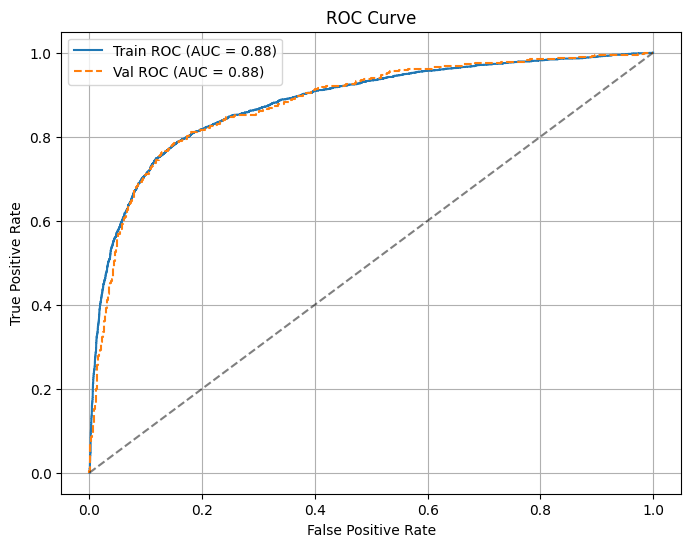

In [39]:
#Побудова ROC-кривих
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC = {train_auc:.2f})')
plt.plot(fpr_val, tpr_val, label=f'Val ROC (AUC = {val_auc:.2f})', linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

**Cпостереження**

AUC ≈ 0.88 — це хороший результат.

Модель добре відділяє клієнтів, які йдуть, від тих, що залишаються.

У Train:

- True Negatives (TN): 9156 — модель правильно передбачила "0"

- False Positives (FP): 402 — модель помилилася, передбачила "1", а там "0"

- False Negatives (FN): 1104 — пропущені "1"

- True Positives (TP): 1338 — модель вгадала "1"

У Validation:

Схожа структура, майже ті ж самі пропорції щой у Train.

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [40]:
#Знайдемо мажоритарний клас
majority_class = y_train.value_counts().idxmax()
print(f"Мажоритарний клас: {majority_class}")

Мажоритарний клас: 0.0


In [41]:
#Створимо передбачення мажоритарної моделі
y_train_majority = [majority_class] * len(y_train)
y_val_majority = [majority_class] * len(y_val)

In [42]:
#Accuracy бейзлайн
train_acc_baseline = accuracy_score(y_train, y_train_majority)
val_acc_baseline = accuracy_score(y_val, y_val_majority)

In [43]:
#Accuracy нашої моделі
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

train_acc_model = accuracy_score(y_train, y_train_pred)
val_acc_model = accuracy_score(y_val, y_val_pred)

In [44]:
#Вивід результатів
print("\n Accuracy порівняння:")
print(f"Baseline Train Accuracy:    {train_acc_baseline:.4f}")
print(f"Model Train Accuracy:       {train_acc_model:.4f}")
print(f"Baseline Validation Accuracy: {val_acc_baseline:.4f}")
print(f"Model Validation Accuracy:    {val_acc_model:.4f}")


 Accuracy порівняння:
Baseline Train Accuracy:    0.7965
Model Train Accuracy:       0.8745
Baseline Validation Accuracy: 0.7967
Model Validation Accuracy:    0.8697


**Спостереження**

- Модельна точність значно краща за бейзлайн:

на тренуванні: 0.8745 vs 0.7965

на валідації: 0.8697 vs 0.7967

Це реальний приріст, а не просто шум — отже, модель точно щось навчилась.

Якість моделі — хороша.


9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

Має сенс зберегти не лише модель, але й повний пакет:

- саму модель LogisticRegression

- StandardScaler

- OneHotEncoder

- список колонок numeric_cols, categorical_cols

Тобто, усе, що потрібно для подальшого передбачення на нових даних.

In [45]:
# Упаковуємо все в словник
save_objects = {
    "model": model,
    "scaler": scaler,
    "encoder": encoder,
    "numeric_cols": numeric_cols,
    "categorical_cols": categorical_cols
}

# Зберігаємо в файл
joblib.dump(save_objects, "log_reg.joblib")
print("Обʼєкти збережено у файл log_reg.joblib")

Обʼєкти збережено у файл log_reg.joblib


In [46]:
#Завантаження з файлу
model_2_pack = joblib.load("log_reg.joblib")

#Отримуємо модель
model_2 = model_2_pack["model"]
print("Модель успішно завантажено як model_2")

Модель успішно завантажено як model_2


In [47]:
# Наприклад, перевіримо чи дає те саме:
print("Accuracy model_2 (validation):",
      model_2.score(X_val, y_val))

print("Model Validation Accuracy:", val_acc_model)

Accuracy model_2 (validation): 0.8696666666666667
Model Validation Accuracy: 0.8696666666666667


10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [48]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(
    model,
    scaler,
    encoder,
    num_imputer,
    cat_imputer,
    numeric_cols,
    categorical_cols,
    input_df: pd.DataFrame):

    df = input_df.copy()

    # Імпутація числових колонок
    df[numeric_cols] = num_imputer.transform(df[numeric_cols])

    # Масштабування числових колонок
    df[numeric_cols] = scaler.transform(df[numeric_cols])

    # Імпутація категоріальних колонок
    df[categorical_cols] = cat_imputer.transform(df[categorical_cols])

    # Кодування категоріальних колонок
    encoded_array = encoder.transform(df[categorical_cols])
    encoded_cols = encoder.get_feature_names_out(categorical_cols)
    encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=df.index)

    # Об'єднання всіх колонок
    X_input = pd.concat([df[numeric_cols], encoded_df], axis=1)

    # Прогнозування
    prob = model.predict_proba(X_input)[:, 1]
    return prob

In [49]:
probs = predict_raw_df(
    model=model,
    scaler=scaler,
    encoder=encoder,
    num_imputer=num_imputer,
    cat_imputer=cat_imputer,
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    input_df=train_df
)


In [50]:
print(probs[:5])

[0.01307073 0.26787339 0.12100962 0.37802645 0.00156622]


11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [51]:
test_csv = data_dir + '/test.csv'

In [52]:
test_raw_df = pd.read_csv(test_csv)

In [53]:
#Отримання передбачень з попередньо визначеною функцією
predicted_probs = predict_raw_df(
    model=model,
    scaler=scaler,
    encoder=encoder,
    num_imputer=num_imputer,
    cat_imputer=cat_imputer,
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    input_df=test_raw_df
)

In [54]:
#Запис результатів у нову колонку
test_raw_df["Exited"] = predicted_probs

In [55]:
test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.069269
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.033349
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.153780
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.198624
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.054094


12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [56]:
#Зчитати шаблон для сабміту
sample_submission_csv = data_dir + '/sample_submission.csv'

In [57]:
submission_df = pd.read_csv(sample_submission_csv)

In [58]:
#Заповнити колонку Exited у шаблоні
submission_df["Exited"] = predicted_probs

In [59]:
submission_df.head()

,id,Exited
0,15000,0.069269
1,15001,0.033349
2,15002,0.153780
3,15003,0.198624
4,15004,0.054094


In [60]:
#Зберегти результат без індексу
submission_df.to_csv("submission_log_reg.csv", index=False)